# File này để so sánh tiêu chí EM và EX giữa Base model và Fine-tuned model

## Cấu trúc bao gồm
- Hàm thực thi exact match
- Hàm thực thi execution accuracy
- Thực hiện đánh giá
- Vẽ biểu đồ

In [1]:
import pandas as pd
import sqlite3
import sqlglot
import re
import torch
from tqdm import tqdm
import torch
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

d:\python-workspace\NL2SQL-chat\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
SYSTEM_PROMPT = """You are a highly specialized NL2SQL engine. Your ONLY task is to translate natural language into accurate SQL queries based on the provided schema.

CRITICAL RULES:
1. Output EXACTLY ONE valid SQL query.
2. DO NOT include any greetings, explanations, or conversational text before or after the query.
3. DO NOT wrap the SQL query in markdown formatting blocks (e.g., strictly NO ```sql or ``` tags). Return raw text only.

Schema: \n"""

## Hàm thực thi Exact Match

In [3]:
import sqlglot

def exact_match_compare(pred_sql: str, ground_sql: str) -> bool:
    """
    Đánh giá tiêu chí Exact Match cho model Text-to-SQL.
    Chuẩn hóa format, khoảng trắng và keyword trước khi so sánh.
    """
    # 1. Kiểm tra và chuẩn hóa câu SQL sinh ra từ model (Pred)
    try:
        # Sử dụng dialect "sqlite" đồng nhất với code Execution của bạn
        pred_ast = sqlglot.parse_one(pred_sql, dialect="sqlite")
        # Xuất ra chuỗi SQL đã được chuẩn hóa format
        pred_norm = pred_ast.sql(dialect="sqlite")
    except sqlglot.errors.SqlglotError:
        print("Lệnh SQL tạo ra bị lỗi cú pháp, Exact Match trả về False")
        return False
    
    # 2. Kiểm tra và chuẩn hóa câu SQL thực tế (Ground truth)
    try:
        ground_ast = sqlglot.parse_one(ground_sql, dialect="sqlite")
        ground_norm = ground_ast.sql(dialect="sqlite")
    except sqlglot.errors.SqlglotError:
        print("Lệnh SQL ground truth bị lỗi cú pháp")
        return False
        
    # 3. So sánh Exact Match
    # Đưa tất cả về chữ thường (lowercase) để đảm bảo không bị sai lệch 
    # do cách viết hoa/thường của tên bảng, cột hoặc alias.
    is_exact_match = pred_norm.lower() == ground_norm.lower()
    
    if not is_exact_match:
        print(f"Khác biệt Exact Match:\n - Gold: {ground_norm}\n - Pred: {pred_norm}")
        
    return is_exact_match

## Hàm hỗ trợ và hàm thực thi Exact Match và Execution Accuracy

In [ ]:
def _normalize_value(val):
    if val is None:
        return None
    if isinstance(val, float):
        return round(val, 4)
    if isinstance(val, str):
        stripped = val.strip()
        if re.match(r"^\d{4}-\d{2}-\d{2}$", stripped):
            return stripped
        return stripped.lower()
    return val

def _normalize_row(row: tuple):
    return tuple(_normalize_value(v) for v in row)

def _has_order_by(sql: str):
    return bool(re.search(r"\bORDER\s+BY\b", sql, re.IGNORECASE))

def exact_match_compare(pred_sql: str, ground_sql: str) -> bool:
    try:
        pred_norm = sqlglot.parse_one(pred_sql, dialect="sqlite").sql(dialect="sqlite")
        ground_norm = sqlglot.parse_one(ground_sql, dialect="sqlite").sql(dialect="sqlite")
        return pred_norm.lower() == ground_norm.lower()
    except sqlglot.errors.SqlglotError:
        return False

def execute_and_compare(
        pred_sql: str,
        ground_sql: str,
        cursor
):
    # Kiểm tra cú pháp
    try:
        sqlglot.parse_one(pred_sql, dialect="sqlite")
    except sqlglot.errors.SqlglotError:
        print("Lệnh SQL tạo ra bị lỗi cú pháp, trả về kết quả False")
        return False
    
    # Thực thi SQL ground truth
    try:
        cursor.execute(ground_sql)
        ground_rows = [_normalize_row(r) for r in cursor.fetchall()]
    except sqlite3.Error:
        print("Lệnh SQL thực tế bị lỗi")
        return False
    
    # Thực thi SQL pred
    try:
        cursor.execute(pred_sql)
        pred_rows = [_normalize_row(r) for r in cursor.fetchall()]
    except sqlite3.Error:
        print("Lệnh SQL bị ảo giác, trả về False")
        return False

    ground_has_order = _has_order_by(ground_sql)

    if ground_has_order:
        return pred_rows == ground_rows
    else:
        try:
            return set(map(frozenset, ground_rows)) == set(map(frozenset, pred_rows))
        except TypeError:
            # Fallback khi row chứa kiểu không hash được
            return sorted(ground_rows) == sorted(pred_rows)

## Hàm đánh giá tổng hợp

In [14]:
def evaluate_text_to_sql(model, tokenizer, csv_path: str, db_path: str, device: str = torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    """
    Hàm đánh giá toàn diện model Text-to-SQL.
    
    Args:
        model: Hugging Face model
        tokenizer: Hugging Face tokenizer
        csv_path: Đường dẫn tới file CSV (cột: natural_language_query, gold_sql, context)
        db_path: Đường dẫn tới database SQLite để test Execution Accuracy
        device: "cuda" hoặc "cpu"
        
    Returns:
        tuple: (Exact Match Score, Execution Accuracy Score)
    """
    # Đọc dữ liệu
    df = pd.read_csv(csv_path)
    total_samples = len(df)
    
    em_correct = 0
    ex_correct = 0
    
    # Kết nối tới Database để chạy test
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    em_dict = dict()
    ex_dict = dict()
    
    model.eval()
    
    # Dùng tqdm để hiển thị thanh tiến trình
    for index, row in tqdm(df.iterrows(), total=total_samples, desc="Evaluating"):
        nlq = row['natural_language_query']
        gold_sql = row['gold_sql']
        context = row['context']
        
        # 1. Tạo Prompt (Bạn có thể tinh chỉnh format này theo cách model của bạn được fine-tune)
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT + context},
            {"role": "user", "content": nlq}
        ]
        input_text =tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )
        tokens = tokenizer(input_text, return_tensors="pt").to(model.device)
        prompt_length = tokens["input_ids"].shape[1]

        with torch.no_grad():
            output = model.generate(
                **tokens,
                max_new_tokens=200,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        generated_tokens = output[0][prompt_length:]
        pred_sql = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
        
        # 4. Đánh giá Exact Match
        is_em = exact_match_compare(pred_sql, gold_sql)
        if is_em:
            em_correct += 1
        em_dict[index] = is_em
            
        # 5. Đánh giá Execution Accuracy
        is_ex = execute_and_compare(pred_sql, gold_sql, cursor)
        if is_ex:
            ex_correct += 1
        ex_dict[index] = is_ex
            
    conn.close()
    
    # Tính toán phần trăm (0.0 -> 1.0)
    em_score = em_correct / total_samples
    ex_score = ex_correct / total_samples
    
    print("\n" + "="*40)
    print("KẾT QUẢ ĐÁNH GIÁ (EVALUATION RESULTS)")
    print("="*40)
    print(f"Tổng số mẫu: {total_samples}")
    print(f"Exact Match (EM):          {em_score * 100:.2f}% ({em_correct}/{total_samples})")
    print(f"Execution Accuracy (EX):   {ex_score * 100:.2f}% ({ex_correct}/{total_samples})")
    
    return em_score, ex_score, em_dict, ex_dict

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "Qwen/Qwen2.5-Coder-3B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map=device,
)
# model.config.use_cache = False
# model.config.pretraining_tp = 1

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Coder-3B-Instruct")
csv_path = os.path.join(os.path.join(root, "data"), "em_ea_eval_data.csv")
db_path = os.path.join(os.path.join(root, "data"), "EA_eval.db")

Loading weights: 100%|██████████| 434/434 [00:15<00:00, 27.15it/s] 


In [15]:
base_em_score, base_ex_score,base_em_dict, base_ex_dict = evaluate_text_to_sql(model, tokenizer, csv_path, db_path)
print("=== Base Model: ===")
print(f"Exact Match: {base_em_score}")
print(f"Execution Accuracy: {base_ex_score}")

Evaluating:  20%|██        | 20/100 [03:11<16:59, 12.74s/it]

Lệnh SQL bị ảo giác, trả về False


Evaluating:  30%|███       | 30/100 [04:58<13:49, 11.84s/it]

Lệnh SQL bị ảo giác, trả về False


Evaluating:  54%|█████▍    | 54/100 [08:09<10:23, 13.55s/it]

...

Lệnh SQL bị ảo giác, trả về False


Evaluating:  91%|█████████ | 91/100 [20:46<02:10, 14.51s/it]

Lệnh SQL bị ảo giác, trả về False


Evaluating: 100%|██████████| 100/100 [22:43<00:00, 13.63s/it]


KẾT QUẢ ĐÁNH GIÁ (EVALUATION RESULTS)
Tổng số mẫu: 100
Exact Match (EM):          29.00% (29/100)
Execution Accuracy (EX):   63.00% (63/100)
=== Base Model: ===
Exact Match: 0.29
Execution Accuracy: 0.63


In [16]:
adapter_path = os.path.join(os.path.join(root, "save_model"), "best-checkpoint-39290")
finetuned_model = PeftModel.from_pretrained(model, adapter_path)
finetuned_em_score, finetuned_ex_score, finetuned_em_dict, finetuned_ex_dict = evaluate_text_to_sql(finetuned_model, tokenizer, csv_path, db_path)
print("=== Fine-tuned Model: ===")
print(f"Exact Match: {finetuned_em_score}")
print(f"Execution Accuracy: {finetuned_ex_score}")

d:\python-workspace\NL2SQL-chat\myenv\lib\site-packages\peft\tuners\tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
Evaluating:  20%|██        | 20/100 [03:08<16:16, 12.20s/it]

Lệnh SQL bị ảo giác, trả về False


Evaluating:  54%|█████▍    | 54/100 [08:27<10:16, 13.41s/it]

Lệnh SQL bị ảo giác, trả về False


Evaluating:  66%|██████▌   | 66/100 [12:21<13:43, 24.23s/it]

...

Lệnh SQL bị ảo giác, trả về False


Evaluating:  94%|█████████▍| 94/100 [21:47<01:14, 12.37s/it]

Lệnh SQL bị ảo giác, trả về False


Evaluating: 100%|██████████| 100/100 [23:11<00:00, 13.92s/it]


KẾT QUẢ ĐÁNH GIÁ (EVALUATION RESULTS)
Tổng số mẫu: 100
Exact Match (EM):          24.00% (24/100)
Execution Accuracy (EX):   60.00% (60/100)
=== Fine-tuned Model: ===
Exact Match: 0.24
Execution Accuracy: 0.6


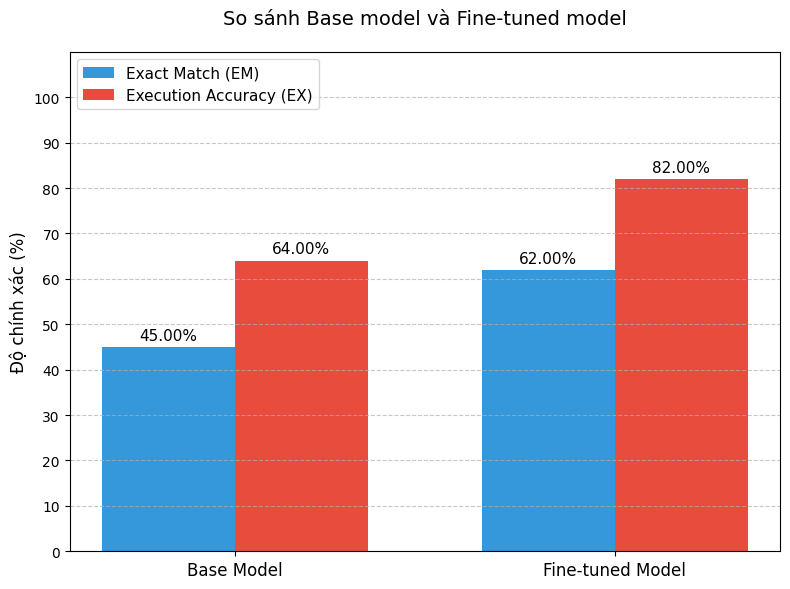

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(base_model_em, base_model_ex, finetuned_model_em, finetuned_model_ex):
    """
    Vẽ biểu đồ cột ghép so sánh Base Model và Fine-tuned Model.
    Các tham số đầu vào là giá trị phần trăm (0 - 100).
    """
    # 1. Chuẩn bị dữ liệu
    labels = ['Base Model', 'Fine-tuned Model']
    em_scores = [base_model_em, finetuned_model_em]
    ex_scores = [base_model_ex, finetuned_model_ex]

    # Vị trí của các nhóm trên trục X
    x = np.arange(len(labels))  
    # Độ rộng của mỗi cột
    width = 0.35  

    # 2. Tạo figure và axes
    fig, ax = plt.subplots(figsize=(8, 6))

    # Vẽ các cột
    # Dịch cột EM sang trái một nửa độ rộng (width/2)
    rects1 = ax.bar(x - width/2, em_scores, width, label='Exact Match (EM)', color='#3498db') 
    # Dịch cột EX sang phải một nửa độ rộng (width/2)
    rects2 = ax.bar(x + width/2, ex_scores, width, label='Execution Accuracy (EX)', color='#e74c3c')

    # 3. Định dạng biểu đồ
    ax.set_ylabel('Độ chính xác (%)', fontsize=12)
    ax.set_title('So sánh Base model và Fine-tuned model', fontsize=14, pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=12)
    
    # Thiết lập giới hạn trục Y từ 0 đến 100 (cộng thêm chút khoảng trống để hiển thị text)
    ax.set_ylim(0, 110) 
    # Chỉ hiển thị tick đến 100
    ax.set_yticks(np.arange(0, 101, 10)) 

    # Thêm chú thích (Legend)
    ax.legend(loc='upper left', fontsize=11)

    # 4. Thêm text hiển thị % trên đầu mỗi cột
    # Chức năng bar_label có sẵn từ matplotlib >= 3.4
    ax.bar_label(rects1, fmt='%.2f%%', padding=3, fontsize=11)
    ax.bar_label(rects2, fmt='%.2f%%', padding=3, fontsize=11)

    # Thêm lưới mờ (grid) cho trục Y để dễ nhìn
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Hiển thị layout gọn gàng
    fig.tight_layout()

    # Hiển thị biểu đồ
    plt.show()


plot_model_comparison(
    base_model_em=45, 
    base_model_ex=64, 
    finetuned_model_em=62, 
    finetuned_model_ex=82
)